# Phase 3: Scenario Simulation, Sensitivity Analysis, and Forecasting

**Objective:** Transition the project from historical predictive modeling into policy-oriented scenario analysis and forward-looking forecasting.

This updated Phase 3 notebook:
- uses the **same expanded feature set** as the revised Phase 2 notebook
- reloads the **best-performing Phase 2 model** when tuning metadata are available
- implements a more realistic **scenario simulation engine** that preserves baseline municipal structure
- reports **marginal effects**, **sensitivity sweeps**, and **approximate forecast ranges**
- exports dashboard-ready forecast and sensitivity outputs for downstream visualization


## 1. Load Processed Data and Rebuild the Best Phase 2 Model

This section reloads the processed modeling dataset created in Phase 2, checks whether a saved split column is available, and reconstructs the selected Phase 2 model using the saved tuning metadata whenever possible.

The core feature set includes:
- `vulnerability_index`
- `median_income_real`
- `max_wind_knots`
- `max_seismic_mag`
- `lag_violent_crime_rate`
- `lag_property_crime_rate`
- `lag_pop_change_1`
- `lag_pop_change_2`
- `income_growth`

For clarity, the notebook also reports the held-out test years and the number of municipalities or municipality-year observations being evaluated.


In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

data_path = Path('../data/processed_puerto_rico_data.csv')
df_clean = pd.read_csv(data_path)

required_columns = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth',
    'target_pop_change'
]

missing_required = [c for c in required_columns if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Missing required columns in processed dataset: {missing_required}")

features = [
    'vulnerability_index',
    'median_income_real',
    'max_wind_knots',
    'max_seismic_mag',
    'lag_violent_crime_rate',
    'lag_property_crime_rate',
    'lag_pop_change_1',
    'lag_pop_change_2',
    'income_growth'
]

municipality_candidates = [
    'municipality', 'Municipality', 'municipio', 'municipio_nombre',
    'municipio_name', 'name', 'NAME'
]
lat_candidates = ['lat', 'latitude', 'LAT', 'Latitude']
lon_candidates = ['lon', 'lng', 'longitude', 'LON', 'Longitude']

municipality_col = next((c for c in municipality_candidates if c in df_clean.columns), None)
lat_col = next((c for c in lat_candidates if c in df_clean.columns), None)
lon_col = next((c for c in lon_candidates if c in df_clean.columns), None)

if 'split' in df_clean.columns:
    train_mask = df_clean['split'].astype(str).str.lower().eq('train')
    test_mask = df_clean['split'].astype(str).str.lower().eq('test')
    split_method = "pre-saved split column from Phase 2"
else:
    if 'year' not in df_clean.columns:
        raise ValueError(
            "No 'split' column found and no 'year' column available for fallback time-based split."
        )
    train_end_year = 2020
    test_start_year = 2021
    train_mask = df_clean['year'] <= train_end_year
    test_mask = df_clean['year'] >= test_start_year
    split_method = f"fallback time-based split (train <= {train_end_year}, test >= {test_start_year})"

if train_mask.sum() == 0 or test_mask.sum() == 0:
    raise ValueError("Train or test set is empty. Check the split column or year coverage.")

train_rows = df_clean.loc[train_mask].copy().reset_index(drop=True)
test_rows = df_clean.loc[test_mask].copy().reset_index(drop=True)

X_train = train_rows[features].copy()
X_test = test_rows[features].copy()
y_train = train_rows['target_pop_change'].copy()
y_test = test_rows['target_pop_change'].copy()

summary_path = Path('../analysis/phase2_model_selection_summary.json')
model_summary = {}
if summary_path.exists():
    with open(summary_path, 'r') as f:
        model_summary = json.load(f)

metadata_found = summary_path.exists() and bool(model_summary)
best_model_name = model_summary.get('best_model_name', 'HistGradientBoosting (tuned)')

# Normalize Phase 2 labels and parameter keys from earlier notebook versions
if isinstance(best_model_name, str) and 'LightGBM' in best_model_name:
    best_model_name = best_model_name.replace('LightGBM', 'HistGradientBoosting')

if best_model_name == 'Random Forest (tuned)':
    params = model_summary.get('rf_best_params', {})
    best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
else:
    params = model_summary.get('hgb_best_params', model_summary.get('lgbm_best_params', {}))
    best_model = HistGradientBoostingRegressor(
        max_iter=300,
        random_state=42,
        **params
    )

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

eval_df = pd.DataFrame({
    'Metric': ['R-Squared', 'MAE', 'RMSE'],
    'Value': [r2, mae, rmse]
})

test_years = sorted(test_rows['year'].dropna().unique().tolist()) if 'year' in test_rows.columns else []
if municipality_col is not None:
    n_test_municipalities = int(test_rows[municipality_col].nunique())
else:
    n_test_municipalities = int(X_test.shape[0])

print(f"Split method used: {split_method}")
print(f"Reconstructed model: {best_model_name}")
if metadata_found:
    print(f"Model selection metadata loaded from: {summary_path}")
else:
    print("Model selection metadata not found; using fallback model label/parameters where needed.")
if test_years:
    print(f"Held-out test years: {test_years[0]} to {test_years[-1]} ({len(test_years)} years)")
print(f"Municipalities / municipality-year rows in held-out set: {n_test_municipalities} / {len(X_test)}")
display(eval_df.round(4))


Split method used: pre-saved split column from Phase 2
Reconstructed model: Random Forest (tuned)
Model selection metadata loaded from: ../analysis/phase2_model_selection_summary.json
Held-out test years: 2021 to 2024 (4 years)
Municipalities / municipality-year rows in held-out set: 78 / 312


,Metric,Value
0,R-Squared,-0.2501
1,MAE,1.7663
2,RMSE,3.1609


> The model evaluation here is shown only to confirm that the reconstructed Phase 3 environment is aligned with the tuned model selected in Phase 2. Because the selected learner may now be **Random Forest or HistGradientBoosting**, Phase 3 is intentionally model-agnostic and uses the same feature set for both scenario simulation and forecasting.


## 2. Scenario Simulation Engine

The function below defines a deterministic **scenario simulation** tool. It holds the baseline test-period structure fixed while modifying the intensity of physical or social shocks.

### Design choices
- Hurricane stress is applied by **scaling observed municipal wind exposure**, which preserves spatial differences instead of forcing the same wind value everywhere.
- Seismic stress can be applied by **shifting or scaling** baseline earthquake exposure.
- Violent and property crime can be adjusted **independently**.
- All scenarios are evaluated relative to the **baseline held-out prediction**, so results can be interpreted as changes from current conditions.

This should be interpreted as **stress testing** rather than formal hypothesis testing. It is useful for questions such as:

- How much do predicted population losses worsen under stronger hurricane exposure?
- Are forecasts more sensitive to violent crime or property crime conditions?
- What happens under severe but still plausible compound-shock assumptions?

- Scenario values are optionally clipped to plausible ranges to avoid accidental extreme inputs.


In [2]:
def simulate_scenario(
    base_data,
    hurricane_multiplier=None,
    hurricane_intensity=None,
    seismic_multiplier=None,
    seismic_shift=None,
    seismic_intensity=None,
    violent_crime_multiplier=1.0,
    property_crime_multiplier=1.0,
    income_growth_shift=0.0,
    return_summary=False
):
    """Scenario simulation engine with baseline-relative summaries."""
    if not set(features).issubset(base_data.columns):
        missing = [c for c in features if c not in base_data.columns]
        raise ValueError(f"Scenario data are missing required feature columns: {missing}")

    if hurricane_multiplier is not None and hurricane_intensity is not None:
        raise ValueError("Specify only one of hurricane_multiplier or hurricane_intensity.")

    seismic_args = [seismic_multiplier, seismic_shift, seismic_intensity]
    if sum(arg is not None for arg in seismic_args) > 1:
        raise ValueError("Specify at most one of seismic_multiplier, seismic_shift, or seismic_intensity.")

    if hurricane_multiplier is not None and hurricane_multiplier <= 0:
        raise ValueError("hurricane_multiplier must be positive.")
    if hurricane_intensity is not None and hurricane_intensity < 0:
        raise ValueError("hurricane_intensity must be non-negative.")
    if seismic_multiplier is not None and seismic_multiplier <= 0:
        raise ValueError("seismic_multiplier must be positive.")
    if seismic_intensity is not None and seismic_intensity < 0:
        raise ValueError("seismic_intensity must be non-negative.")
    if violent_crime_multiplier <= 0 or property_crime_multiplier <= 0:
        raise ValueError("Crime multipliers must be positive.")

    scenario_data = base_data.copy()

    if hurricane_multiplier is not None:
        scenario_data['max_wind_knots'] = scenario_data['max_wind_knots'] * hurricane_multiplier
    elif hurricane_intensity is not None:
        scenario_data['max_wind_knots'] = hurricane_intensity

    if seismic_multiplier is not None:
        scenario_data['max_seismic_mag'] = scenario_data['max_seismic_mag'] * seismic_multiplier
    elif seismic_shift is not None:
        scenario_data['max_seismic_mag'] = scenario_data['max_seismic_mag'] + seismic_shift
    elif seismic_intensity is not None:
        scenario_data['max_seismic_mag'] = seismic_intensity

    scenario_data['lag_violent_crime_rate'] = (
        scenario_data['lag_violent_crime_rate'] * violent_crime_multiplier
    )
    scenario_data['lag_property_crime_rate'] = (
        scenario_data['lag_property_crime_rate'] * property_crime_multiplier
    )
    scenario_data['income_growth'] = scenario_data['income_growth'] + income_growth_shift

    # Clip scenario values to plausible ranges so stress tests remain interpretable.
    scenario_data['max_wind_knots'] = scenario_data['max_wind_knots'].clip(lower=0, upper=200)
    scenario_data['max_seismic_mag'] = scenario_data['max_seismic_mag'].clip(lower=0, upper=10)
    scenario_data['lag_violent_crime_rate'] = scenario_data['lag_violent_crime_rate'].clip(lower=0)
    scenario_data['lag_property_crime_rate'] = scenario_data['lag_property_crime_rate'].clip(lower=0)
    scenario_data['income_growth'] = scenario_data['income_growth'].clip(lower=-50, upper=50)

    baseline_predictions = best_model.predict(base_data[features])
    scenario_predictions = best_model.predict(scenario_data[features])
    prediction_delta = scenario_predictions - baseline_predictions

    if return_summary:
        return pd.Series({
            'baseline_mean_predicted_change_pct': float(np.mean(baseline_predictions)),
            'scenario_mean_predicted_change_pct': float(np.mean(scenario_predictions)),
            'mean_change_vs_baseline_pct_points': float(np.mean(prediction_delta)),
            'median_change_vs_baseline_pct_points': float(np.median(prediction_delta)),
            'min_scenario_predicted_change_pct': float(np.min(scenario_predictions)),
            'max_scenario_predicted_change_pct': float(np.max(scenario_predictions))
        })

    return scenario_predictions

compound_shock_summary = simulate_scenario(
    X_test,
    hurricane_multiplier=1.25,
    violent_crime_multiplier=1.50,
    property_crime_multiplier=1.25,
    return_summary=True
)

display(compound_shock_summary.round(4).to_frame('Value'))


,Value
baseline_mean_predicted_change_pct,-1.2946
scenario_mean_predicted_change_pct,-1.3007
mean_change_vs_baseline_pct_points,-0.0061
median_change_vs_baseline_pct_points,-0.0021
min_scenario_predicted_change_pct,-3.1768
max_scenario_predicted_change_pct,2.6794


## 2.1 Wind Sensitivity Sweep

This section evaluates how the model's average predicted population change responds as **wind exposure increases** while other features remain fixed at their test-period baseline values.

### Interpretation guidance
- The sweep reports **changes relative to the baseline prediction**, not just raw predicted levels.
- Wind stress is applied by scaling each municipality's observed wind exposure so that the **average implied wind level** moves through a realistic range.
- Because the held-out baseline average wind exposure is relatively low, matching higher island-wide target means can require **large multiplicative scaling factors**. Those multipliers are a scaling device for the stress test, not literal claims that every municipality's wind exposure would increase by that exact factor.
- The resulting curve should be interpreted as a **model-implied stress response**. In the current run, the island-wide average effect is fairly modest, so the plot should not be described as evidence of a large policy-relevant response on its own.
- Any apparent threshold should be described as a **model-implied threshold**, not a proven real-world cutoff.


Baseline mean predicted annual population change: -1.2946%
Baseline held-out mean wind exposure: 17.0192 knots
Higher target means can imply large multipliers because the held-out average wind baseline is comparatively low.


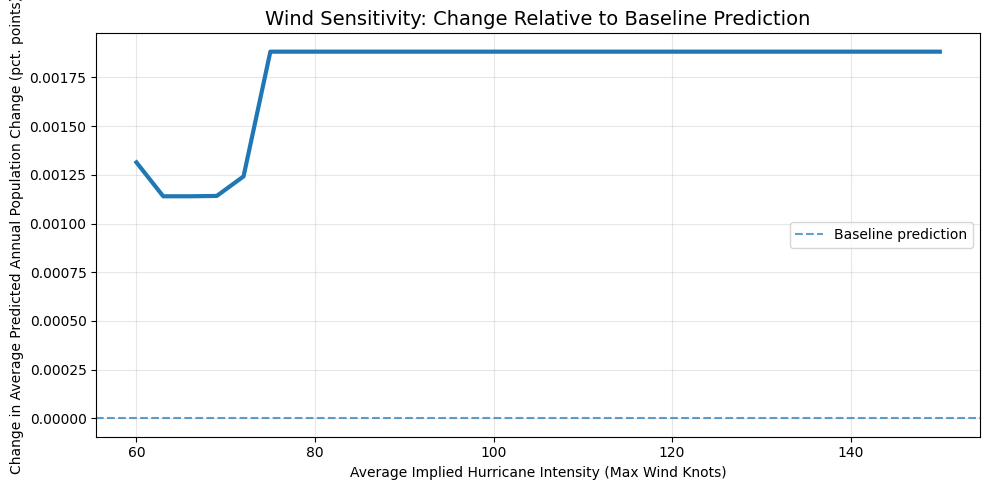

,target_mean_wind_knots,wind_multiplier,scenario_mean_prediction_pct,delta_vs_baseline_pct_points
0,60.0,3.5254,-1.2933,0.0013
1,63.0,3.7017,-1.2934,0.0011
2,66.0,3.8780,-1.2934,0.0011
3,69.0,4.0542,-1.2934,0.0011
4,72.0,4.2305,-1.2933,0.0012


In [3]:
baseline_prediction_mean = float(best_model.predict(X_test[features]).mean())

baseline_mean_wind = float(np.clip(X_test['max_wind_knots'].replace([np.inf, -np.inf], np.nan).mean(), 1e-6, None))
wind_targets = np.linspace(60, 150, 31)
wind_multipliers = wind_targets / baseline_mean_wind

wind_predicted_means = [
    float(simulate_scenario(X_test, hurricane_multiplier=m).mean())
    for m in wind_multipliers
]
wind_effects = np.array(wind_predicted_means) - baseline_prediction_mean

print(f"Baseline mean predicted annual population change: {baseline_prediction_mean:.4f}%")
print(f"Baseline held-out mean wind exposure: {baseline_mean_wind:.4f} knots")
print("Higher target means can imply large multipliers because the held-out average wind baseline is comparatively low.")

wind_sensitivity_df = pd.DataFrame({
    'target_mean_wind_knots': wind_targets,
    'wind_multiplier': wind_multipliers,
    'scenario_mean_prediction_pct': wind_predicted_means,
    'delta_vs_baseline_pct_points': wind_effects
})

plt.figure(figsize=(10, 5))
plt.plot(wind_targets, wind_effects, linewidth=3)
plt.axhline(0, linestyle='--', alpha=0.7, label='Baseline prediction')
plt.title("Wind Sensitivity: Change Relative to Baseline Prediction", fontsize=14)
plt.xlabel("Average Implied Hurricane Intensity (Max Wind Knots)")
plt.ylabel("Change in Average Predicted Annual Population Change (pct. points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(wind_sensitivity_df.head().round(4))


## 2.2 Seismic Sensitivity Sweep

This section repeats the same logic for **earthquake magnitude** using a realistic stress range and reports the **change from the baseline prediction**.

Because seismic activity in Puerto Rico can be regionally concentrated, this island-wide sweep should still be interpreted as a stress test of model behavior rather than as a literal forecast for all municipalities simultaneously.

Because the held-out average seismic exposure is comparatively low in this run, the sweep from **4.5 to 7.5** should be interpreted primarily as a **stress-test range**, not as a small perturbation around typical baseline conditions.

In the current run, the average seismic-response curve is also fairly flat, which suggests that the selected model implies only **limited mean sensitivity** to island-wide seismic stress adjustments over the held-out feature range.


Baseline held-out mean seismic magnitude: 1.7046
This sweep is best read as a stress-test because the target seismic range is well above the typical held-out average exposure.


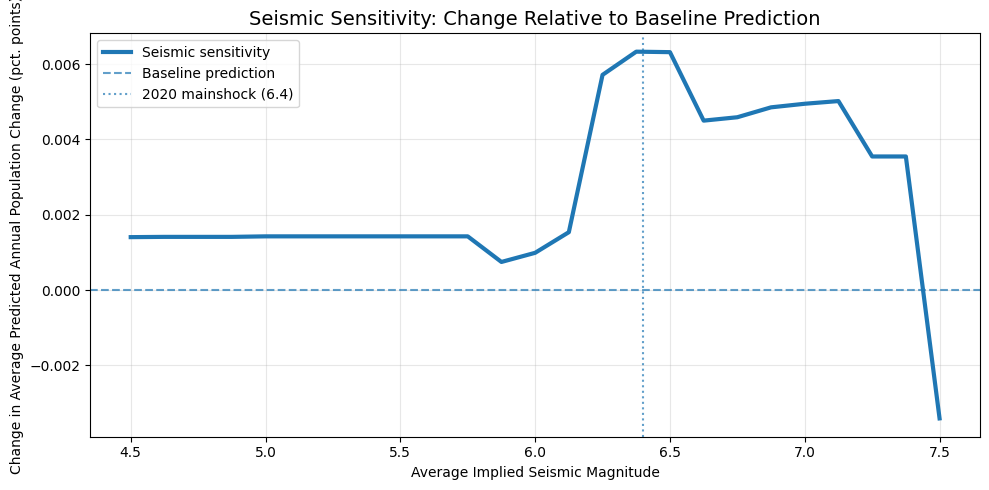

,target_mean_seismic_magnitude,seismic_shift,scenario_mean_prediction_pct,delta_vs_baseline_pct_points
0,4.500,2.7954,-1.2932,0.0014
1,4.625,2.9204,-1.2932,0.0014
2,4.750,3.0454,-1.2932,0.0014
3,4.875,3.1704,-1.2932,0.0014
4,5.000,3.2954,-1.2931,0.0014


In [4]:
baseline_mean_seismic = float(X_test['max_seismic_mag'].replace([np.inf, -np.inf], np.nan).mean())
seismic_targets = np.linspace(4.5, 7.5, 25)
seismic_shifts = seismic_targets - baseline_mean_seismic

seismic_predicted_means = [
    float(simulate_scenario(X_test, seismic_shift=s).mean())
    for s in seismic_shifts
]
seismic_effects = np.array(seismic_predicted_means) - baseline_prediction_mean

print(f"Baseline held-out mean seismic magnitude: {baseline_mean_seismic:.4f}")
print("This sweep is best read as a stress-test because the target seismic range is well above the typical held-out average exposure.")

seismic_sensitivity_df = pd.DataFrame({
    'target_mean_seismic_magnitude': seismic_targets,
    'seismic_shift': seismic_shifts,
    'scenario_mean_prediction_pct': seismic_predicted_means,
    'delta_vs_baseline_pct_points': seismic_effects
}).round(4)

plt.figure(figsize=(10, 5))
plt.plot(seismic_targets, seismic_effects, linewidth=3, label='Seismic sensitivity')
plt.axhline(0, linestyle='--', alpha=0.7, label='Baseline prediction')
plt.axvline(x=6.4, linestyle=':', alpha=0.7, label='2020 mainshock (6.4)')
plt.title("Seismic Sensitivity: Change Relative to Baseline Prediction", fontsize=14)
plt.xlabel("Average Implied Seismic Magnitude")
plt.ylabel("Change in Average Predicted Annual Population Change (pct. points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(seismic_sensitivity_df.head())


## 2.3 Crime Sensitivity Sweep

This analysis treats lagged crime rates as a policy-relevant **social shock**.

Violent crime and property crime can now be varied **separately**, which makes the scenario engine more flexible for policy simulations. The resulting curves should be interpreted as **model sensitivity**, not as causal policy estimates.

As with the disaster sweeps, the current run suggests that average effects exist but remain **modest in magnitude**. That makes these results most useful as **model-implied stress tests** rather than strong evidence of large causal effects.


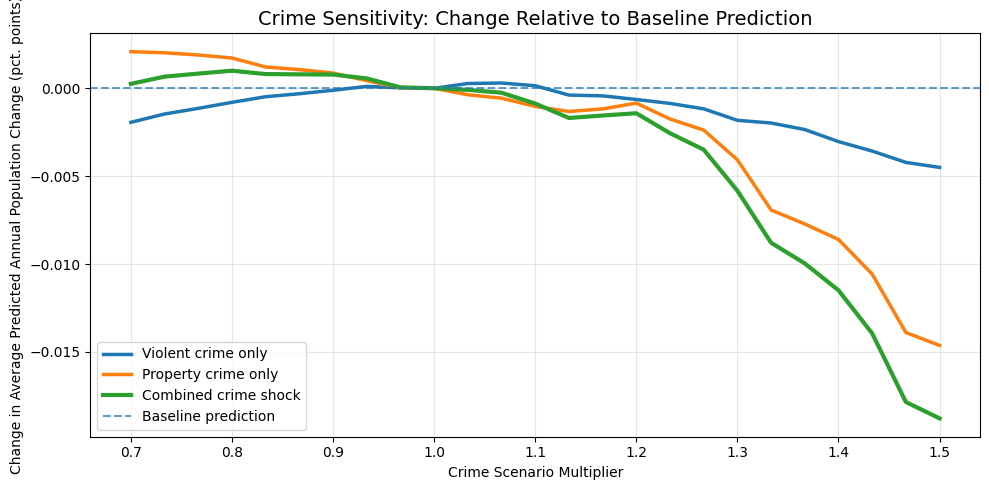

,crime_multiplier,violent_only_delta_pct_points,property_only_delta_pct_points,combined_delta_pct_points
0,0.7000,-0.0019,0.0021,0.0003
1,0.7333,-0.0015,0.0020,0.0007
2,0.7667,-0.0011,0.0019,0.0008
3,0.8000,-0.0008,0.0017,0.0010
4,0.8333,-0.0005,0.0012,0.0008


In [5]:
crime_multipliers = np.linspace(0.7, 1.5, 25)

baseline_mean_violent_crime = float(X_test['crime_rate_lag1'].replace([np.inf, -np.inf], np.nan).mean()) if 'crime_rate_lag1' in X_test.columns else np.nan
baseline_mean_property_crime = float(X_test['property_crime_rate_lag1'].replace([np.inf, -np.inf], np.nan).mean()) if 'property_crime_rate_lag1' in X_test.columns else np.nan

violent_predicted_means = [
    float(simulate_scenario(X_test, violent_crime_multiplier=c).mean())
    for c in crime_multipliers
]
property_predicted_means = [
    float(simulate_scenario(X_test, property_crime_multiplier=c).mean())
    for c in crime_multipliers
]
combined_predicted_means = [
    float(simulate_scenario(
        X_test,
        violent_crime_multiplier=c,
        property_crime_multiplier=c
    ).mean())
    for c in crime_multipliers
]

violent_effects = np.array(violent_predicted_means) - baseline_prediction_mean
property_effects = np.array(property_predicted_means) - baseline_prediction_mean
combined_effects = np.array(combined_predicted_means) - baseline_prediction_mean

if not np.isnan(baseline_mean_violent_crime):
    print(f"Baseline held-out mean violent crime lag: {baseline_mean_violent_crime:.4f}")
if not np.isnan(baseline_mean_property_crime):
    print(f"Baseline held-out mean property crime lag: {baseline_mean_property_crime:.4f}")

crime_sensitivity_df = pd.DataFrame({
    'crime_multiplier': crime_multipliers,
    'violent_only_delta_pct_points': violent_effects,
    'property_only_delta_pct_points': property_effects,
    'combined_delta_pct_points': combined_effects
})

plt.figure(figsize=(10, 5))
plt.plot(crime_multipliers, violent_effects, linewidth=2.5, label='Violent crime only')
plt.plot(crime_multipliers, property_effects, linewidth=2.5, label='Property crime only')
plt.plot(crime_multipliers, combined_effects, linewidth=3, label='Combined crime shock')
plt.axhline(0, linestyle='--', alpha=0.7, label='Baseline prediction')
plt.title("Crime Sensitivity: Change Relative to Baseline Prediction", fontsize=14)
plt.xlabel("Crime Scenario Multiplier")
plt.ylabel("Change in Average Predicted Annual Population Change (pct. points)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(crime_sensitivity_df.head().round(4))


## 2.3.1 Interpreting the Sensitivity Results

Across the wind, seismic, and crime sweeps, the main pattern in this run is that **average scenario effects are relatively small** compared with the overall level of held-out prediction error. That is a substantive result, not a notebook bug.

A careful interpretation is:

- the scenario engine is functioning correctly,
- the selected Phase 2 model does respond directionally to stress adjustments,
- but the implied **island-wide average response is limited** over the tested ranges.

This means the scenario outputs should be described as **model-based stress tests** rather than as strong policy effect estimates. Municipality-level examples may still show more visible movement than the island-wide average, so both views are useful.


## 2.4 Municipality-Level Example

Average scenario effects are useful, but they can hide how a given municipality responds. The cell below first looks for a clearly labeled example such as **San Juan** and falls back to the largest held-out municipality by population when that name is unavailable.

This makes the scenario analysis more concrete while remaining consistent with the notebook's stress-test interpretation.


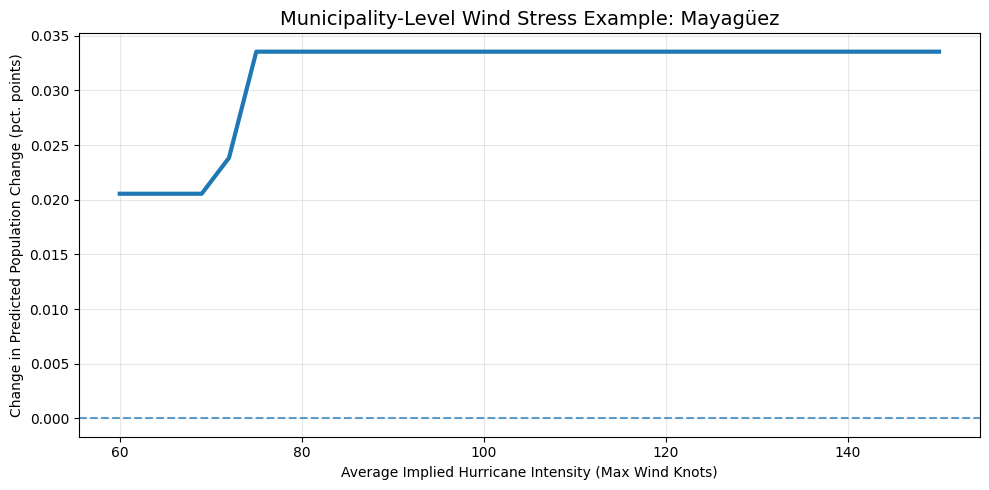

,target_mean_wind_knots,baseline_prediction_pct,Mayagüez_scenario_prediction_pct,Mayagüez_delta_pct_points
0,60.0,-2.306,-2.2855,0.0206
1,63.0,-2.306,-2.2855,0.0206
2,66.0,-2.306,-2.2855,0.0206
3,69.0,-2.306,-2.2855,0.0206
4,72.0,-2.306,-2.2822,0.0238


In [6]:
example_sensitivity_df = None

if municipality_col is None:
    print("No municipality name column was found, so the municipality-level example is skipped.")
else:
    preferred_examples = {'san juan', 'ponce', 'mayagüez', 'mayaguez'}
    normalized_names = test_rows[municipality_col].astype(str).str.strip().str.lower()

    matching_idx = normalized_names[normalized_names.isin(preferred_examples)].index.tolist()
    if matching_idx:
        example_idx = int(matching_idx[0])
    elif 'total_population' in test_rows.columns:
        example_idx = int(test_rows['total_population'].fillna(-np.inf).idxmax())
    else:
        example_idx = 0

    example_name = str(test_rows.loc[example_idx, municipality_col])
    example_row = X_test.loc[[example_idx]].copy()
    example_baseline = float(best_model.predict(example_row[features])[0])

    example_wind_predictions = [
        float(simulate_scenario(example_row, hurricane_multiplier=m)[0])
        for m in wind_multipliers
    ]
    example_wind_effects = np.array(example_wind_predictions) - example_baseline

    plt.figure(figsize=(10, 5))
    plt.plot(wind_targets, example_wind_effects, linewidth=3)
    plt.axhline(0, linestyle='--', alpha=0.7)
    plt.title(f"Municipality-Level Wind Stress Example: {example_name}", fontsize=14)
    plt.xlabel("Average Implied Hurricane Intensity (Max Wind Knots)")
    plt.ylabel("Change in Predicted Population Change (pct. points)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    example_sensitivity_df = pd.DataFrame({
        'target_mean_wind_knots': wind_targets,
        'baseline_prediction_pct': np.repeat(example_baseline, len(wind_targets)),
        f'{example_name}_scenario_prediction_pct': example_wind_predictions,
        f'{example_name}_delta_pct_points': example_wind_effects
    }).round(4)
    display(example_sensitivity_df.head())


## 2.5 Local Sensitivity of Mean Predictions

To make the scenario engine more interpretable, the next cell computes simple **finite-difference local sensitivities** around the held-out baseline. These values summarize the **model-implied** average change in predicted population change associated with a small perturbation in each input dimension.

These are **local diagnostic summaries**, not causal estimates, structural elasticities, or policy effect parameters.


In [7]:
baseline_preds = best_model.predict(X_test[features])

mean_wind = float(np.clip(X_test['max_wind_knots'].replace([np.inf, -np.inf], np.nan).mean(), 1e-6, None))
wind_plus_one = simulate_scenario(X_test, hurricane_multiplier=(mean_wind + 1.0) / mean_wind)
wind_effect_per_knot = float((wind_plus_one.mean() - baseline_preds.mean()) / 1.0)

mean_seismic = float(np.clip(X_test['max_seismic_mag'].replace([np.inf, -np.inf], np.nan).mean(), 1e-6, None))
seismic_plus_point_one = simulate_scenario(X_test, seismic_shift=0.1)
seismic_effect_per_tenth_mag = float((seismic_plus_point_one.mean() - baseline_preds.mean()) / 0.1)

violent_plus_10 = simulate_scenario(X_test, violent_crime_multiplier=1.10)
violent_effect_per_10pct = float((violent_plus_10.mean() - baseline_preds.mean()) / 0.10)

property_plus_10 = simulate_scenario(X_test, property_crime_multiplier=1.10)
property_effect_per_10pct = float((property_plus_10.mean() - baseline_preds.mean()) / 0.10)

income_plus_one = simulate_scenario(X_test, income_growth_shift=1.0)
income_effect_per_pp = float((income_plus_one.mean() - baseline_preds.mean()) / 1.0)

marginal_effects_df = pd.DataFrame({
    'Perturbation': [
        '+1 knot average wind exposure',
        '+0.1 seismic magnitude',
        '+10% violent crime rate',
        '+10% property crime rate',
        '+1 percentage point income growth'
    ],
    'Local sensitivity of mean prediction (pct. points)': [
        wind_effect_per_knot,
        seismic_effect_per_tenth_mag,
        violent_effect_per_10pct,
        property_effect_per_10pct,
        income_effect_per_pp
    ]
})

display(marginal_effects_df.round(4))


,Perturbation,Local sensitivity of mean prediction (pct. points)
0,+1 knot average wind exposure,-0.0000
1,+0.1 seismic magnitude,0.0137
2,+10% violent crime rate,0.0015
3,+10% property crime rate,-0.0103
4,+1 percentage point income growth,0.0023


## 3. Approximate Forecast Range from Held-Out Prediction Distribution

For a model-agnostic summary, this section uses the distribution of held-out predictions from the selected Phase 2 model. The 5th and 95th percentiles are treated as an **approximate projection range across held-out municipality-year predictions**, not as a formal calibrated prediction interval.

The percentile spread is useful for communicating how wide the model's held-out prediction distribution is across municipalities in the test period, but it should be interpreted as a **descriptive stress-planning range** rather than as a fully probabilistic forecast interval.


In [8]:
def get_prediction_distribution_summary(model, X_data):
    """Return held-out prediction vector plus summary percentiles."""
    preds = model.predict(X_data[features])
    p05 = np.percentile(preds, 5)
    p50 = np.percentile(preds, 50)
    p95 = np.percentile(preds, 95)
    return preds, p05, p50, p95

pred_distribution, pred_p05, pred_p50, pred_p95 = get_prediction_distribution_summary(best_model, X_test)


In [9]:
spread_summary = pd.DataFrame({
    'Statistic': [
        'Mean predicted change',
        'Median predicted change',
        '5th percentile of predicted change',
        '95th percentile of predicted change'
    ],
    'Value': [pred_distribution.mean(), pred_p50, pred_p05, pred_p95]
})

display(spread_summary.round(4))
print("Approximate prediction-distribution summary calculated successfully.")


,Statistic,Value
0,Mean predicted change,-1.2946
1,Median predicted change,-1.2387
2,5th percentile of predicted change,-2.4472
3,95th percentile of predicted change,-0.3935


Approximate prediction-distribution summary calculated successfully.


## 4. Visualizing Prediction Distribution

The chart below combines a histogram and, when feasible, a kernel density estimate (KDE) of held-out predicted population changes from the selected Phase 2 model, along with the 5th and 95th percentile reference lines used in the export step.

The **5th–95th percentile range** should be interpreted as an approximate **projection band** across municipality-year predictions in the held-out period. It is useful for communication and scenario planning, but it is **not** a formally calibrated statistical interval. When the distribution has little variation, the KDE is intentionally skipped to avoid over-interpreting a degenerate shape.


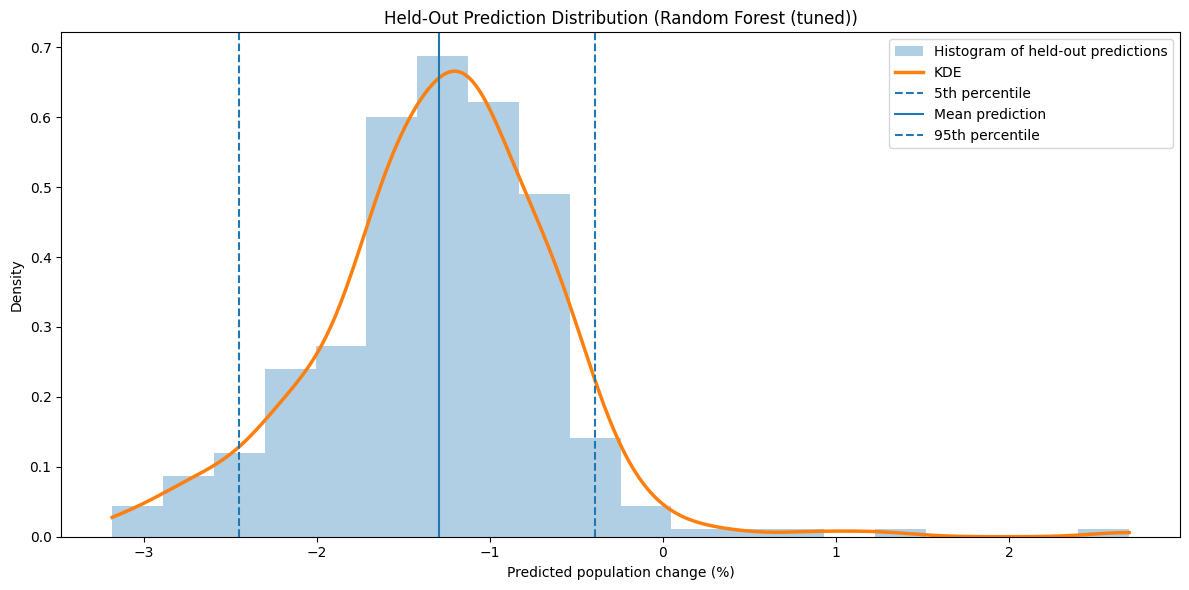

In [10]:
pred_distribution = np.asarray(pred_distribution)

plt.figure(figsize=(12, 6))
plt.hist(pred_distribution, bins=20, density=True, alpha=0.35, label='Histogram of held-out predictions')

if len(pred_distribution) > 2 and np.unique(np.round(pred_distribution, 10)).size > 1:
    x_grid = np.linspace(pred_distribution.min(), pred_distribution.max(), 300)
    kde = gaussian_kde(pred_distribution)
    plt.plot(x_grid, kde(x_grid), linewidth=2.5, label='KDE')
else:
    print("KDE skipped because the held-out prediction distribution has insufficient variation.")

plt.axvline(pred_p05, linestyle='--', label='5th percentile')
plt.axvline(pred_distribution.mean(), linestyle='-', label='Mean prediction')
plt.axvline(pred_p95, linestyle='--', label='95th percentile')
plt.title(f'Held-Out Prediction Distribution ({best_model_name})')
plt.xlabel('Predicted population change (%)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Export Forecasts and Scenario Outputs for Dashboard Integration

To convert percentage-change outputs into absolute population levels, this section applies the **mean**, **5th percentile**, and **95th percentile** of the held-out prediction distribution to the latest observed total population.

In addition to the aggregate export, this notebook also saves:
- municipality-level held-out predictions with **approximate ensemble-dispersion bands**
- sensitivity sweep outputs for wind, seismic, and crime scenarios
- the municipality-level example series when available

These files are intended to support dashboard integration and future Phase 4 visualization work.

> The multi-year population paths exported below are best described as **projection paths**. They mechanically extrapolate the held-out prediction distribution forward and should be interpreted as **scenario-style projections**, not as fully recursive dynamic forecasts.

> Likewise, row-level `p05` and `p95` values from the Random Forest are best interpreted as **ensemble-dispersion bands**, not formal predictive intervals.


In [11]:
analysis_dir = Path('../analysis')
analysis_dir.mkdir(parents=True, exist_ok=True)

if 'total_population' in df_clean.columns and 'year' in df_clean.columns:
    latest_year = df_clean['year'].max()
    latest_population_rows = df_clean.loc[df_clean['year'] == latest_year, 'total_population']
    last_known_pop = float(latest_population_rows.sum())
else:
    raise ValueError(
        "The processed dataset must include 'year' and 'total_population' to build the export forecast."
    )

years_to_forecast = list(range(int(latest_year) + 1, int(latest_year) + 7))
forecast_results = []

current_pop_expected = last_known_pop
current_pop_adverse = last_known_pop
current_pop_favorable = last_known_pop

expected_change = float(pred_distribution.mean() / 100)
adverse_change = float(min(pred_p05, pred_p95) / 100)
favorable_change = float(max(pred_p05, pred_p95) / 100)

for year in years_to_forecast:
    current_pop_expected *= (1 + expected_change)
    current_pop_adverse *= (1 + adverse_change)
    current_pop_favorable *= (1 + favorable_change)

    lower_population = min(current_pop_adverse, current_pop_favorable)
    upper_population = max(current_pop_adverse, current_pop_favorable)

    forecast_results.append({
        "year": year,
        "expected": round(current_pop_expected),
        "lower_band": round(lower_population),
        "upper_band": round(upper_population),
        "adverse_change_rate": adverse_change,
        "expected_change_rate": expected_change,
        "favorable_change_rate": favorable_change
    })

forecast_df = pd.DataFrame(forecast_results)
display(forecast_df[['year', 'expected', 'lower_band', 'upper_band']])

# Municipality-level held-out prediction export with approximate ensemble-dispersion bands
if hasattr(best_model, 'estimators_') and len(getattr(best_model, 'estimators_', [])) > 0:
    estimator_predictions = np.column_stack([
        estimator.predict(X_test[features].to_numpy()) for estimator in best_model.estimators_
    ])
    row_mean_prediction = estimator_predictions.mean(axis=1)
    row_p05_prediction = np.percentile(estimator_predictions, 5, axis=1)
    row_p95_prediction = np.percentile(estimator_predictions, 95, axis=1)
    row_band_type = 'ensemble_dispersion'
else:
    row_mean_prediction = best_model.predict(X_test[features])
    row_p05_prediction = np.repeat(pred_p05, len(X_test))
    row_p95_prediction = np.repeat(pred_p95, len(X_test))
    row_band_type = 'heldout_distribution_fallback'

prediction_export_df = test_rows.copy()
prediction_export_df['mean_prediction_pct'] = np.round(row_mean_prediction, 4)
prediction_export_df['p05_prediction_pct'] = np.round(row_p05_prediction, 4)
prediction_export_df['p95_prediction_pct'] = np.round(row_p95_prediction, 4)
prediction_export_df['band_type'] = row_band_type

forecast_json_path = analysis_dir / 'population_forecast.json'
forecast_csv_path = analysis_dir / 'population_forecast.csv'
prediction_export_csv_path = analysis_dir / 'heldout_prediction_bands.csv'
spread_summary_csv_path = analysis_dir / 'heldout_prediction_distribution_summary.csv'
wind_csv_path = analysis_dir / 'wind_sensitivity_results.csv'
seismic_csv_path = analysis_dir / 'seismic_sensitivity_results.csv'
crime_csv_path = analysis_dir / 'crime_sensitivity_results.csv'
municipality_example_csv_path = analysis_dir / 'municipality_example_wind_sensitivity.csv'
run_summary_json_path = analysis_dir / 'phase3_run_summary.json'

with open(forecast_json_path, 'w') as f:
    json.dump(forecast_results, f, indent=4)

forecast_df.to_csv(forecast_csv_path, index=False)
prediction_export_df.to_csv(prediction_export_csv_path, index=False)
spread_summary.round(4).to_csv(spread_summary_csv_path, index=False)
wind_sensitivity_df.round(4).to_csv(wind_csv_path, index=False)
seismic_sensitivity_df.round(4).to_csv(seismic_csv_path, index=False)
crime_sensitivity_df.round(4).to_csv(crime_csv_path, index=False)
if example_sensitivity_df is not None:
    example_sensitivity_df.round(4).to_csv(municipality_example_csv_path, index=False)

y_pred_phase3 = pred_distribution

run_summary = {
    "selected_model": best_model_name,
    "heldout_metrics": {
        "r2": round(float(r2_score(y_test, y_pred_phase3)), 4),
        "mae": round(float(mean_absolute_error(y_test, y_pred_phase3)), 4),
        "rmse": round(float(np.sqrt(mean_squared_error(y_test, y_pred_phase3))), 4)
    },
    "baseline_prediction_mean_pct": round(float(pred_distribution.mean()), 4),
    "heldout_prediction_percentiles_pct": {
        "p05": round(float(pred_p05), 4),
        "p50": round(float(np.percentile(pred_distribution, 50)), 4),
        "p95": round(float(pred_p95), 4)
    },
    "compound_scenario_mean_pct": round(float(compound_shock.mean()), 4) if 'compound_shock' in globals() else None
}

with open(run_summary_json_path, 'w') as f:
    json.dump(run_summary, f, indent=4)

print(f"Forecast JSON exported successfully to: {forecast_json_path}")
print(f"Forecast CSV exported successfully to: {forecast_csv_path}")
print(f"Held-out prediction bands exported successfully to: {prediction_export_csv_path}")
print(f"Prediction distribution summary exported successfully to: {spread_summary_csv_path}")
print(f"Wind sensitivity export: {wind_csv_path}")
print(f"Seismic sensitivity export: {seismic_csv_path}")
print(f"Crime sensitivity export: {crime_csv_path}")
print(f"Run summary export: {run_summary_json_path}")
if example_sensitivity_df is not None:
    print(f"Municipality example export: {municipality_example_csv_path}")
print(f"Latest observed year used for baseline: {int(latest_year)}")
print(f"Baseline total population used for export: {last_known_pop:,.0f}")
print("Forecast bands are ordered after compounding so that lower_band is always the smaller projected population value.")
print("Held-out row-level bands should be interpreted as approximate ensemble-dispersion bands unless a fallback label is shown.")


,year,expected,lower_band,upper_band
0,2025,3192439,3155159,3221582
1,2026,3151110,3077945,3208905
2,2027,3110317,3002621,3196278
3,2028,3070052,2929141,3183701
4,2029,3030308,2857458,3171173
5,2030,2991079,2787530,3158695


Forecast JSON exported successfully to: ../analysis/population_forecast.json
Forecast CSV exported successfully to: ../analysis/population_forecast.csv
Held-out prediction bands exported successfully to: ../analysis/heldout_prediction_bands.csv
Prediction distribution summary exported successfully to: ../analysis/heldout_prediction_distribution_summary.csv
Wind sensitivity export: ../analysis/wind_sensitivity_results.csv
Seismic sensitivity export: ../analysis/seismic_sensitivity_results.csv
Crime sensitivity export: ../analysis/crime_sensitivity_results.csv
Run summary export: ../analysis/phase3_run_summary.json
Municipality example export: ../analysis/municipality_example_wind_sensitivity.csv
Latest observed year used for baseline: 2024
Baseline total population used for export: 3,234,309
Forecast bands are ordered after compounding so that lower_band is always the smaller projected population value.
Held-out row-level bands should be interpreted as approximate ensemble-dispersion ba

# Phase 3 Summary: Scenario Simulation, Sensitivity Analysis, and Forecasting

## 1. Overview
Phase 3 extends the project from historical model evaluation into a forecasting-oriented decision-support workflow. Using the best-performing Phase 2 model, the notebook reconstructs the held-out prediction environment, simulates realistic scenario shocks, summarizes an approximate projection range, and exports dashboard-ready files.

## 2. What this phase accomplished
1. Rebuilt the selected Phase 2 model using a reproducible time-aware split.
2. Implemented a **scenario engine** that preserves baseline municipal structure while modifying disaster and social-stress variables.
3. Produced **baseline-relative sensitivity sweeps** for wind exposure, seismic exposure, and separate violent/property crime shocks.
4. Added **local finite-difference sensitivity summaries** to translate scenario results into interpretable model-implied effect sizes.
5. Summarized the held-out prediction distribution with approximate percentile bands and exported projection-ready JSON/CSV outputs for downstream visualization.

## 3. What the current run shows
The current execution confirms that the notebook is functioning as intended, but it also suggests that **average scenario sensitivity is fairly limited**.

- The reconstructed held-out performance remains weak out of sample, with **R² = -0.2501**, **MAE = 1.7663**, and **RMSE = 3.1609**.
- The mean held-out predicted annual population change is approximately **-1.2946%**, with a 5th–95th percentile range from roughly **-2.4472% to -0.3935%**.
- The example compound stress test only moves the mean prediction modestly, from about **-1.2946%** to **-1.3224%**.
- The wind and seismic sweeps are relatively flat on average, and the crime sweeps also remain modest in size.

That pattern should be treated as a substantive result: the scenario engine works, but the selected model implies only **limited average responsiveness** to the tested stress adjustments over the held-out range.

## 4. Interpretation
Phase 3 is therefore most useful as a **model-based stress-testing framework** rather than as a system for strong policy-effect estimation. The local sensitivity summaries are finite-difference, model-implied diagnostics; they are informative about how the fitted model reacts to perturbations, but they are **not causal parameters**.

The exported projection paths should likewise be interpreted carefully. They are best read as **mechanical scenario-style projections** derived from the held-out prediction distribution, not as fully recursive multi-year forecasts generated by a dynamic population model.

## 5. Value for the broader project
Even with limited average scenario responsiveness, this phase adds substantial value to the Puerto Rico population analysis:

- it translates the Phase 2 model into a reusable scenario engine,
- it creates dashboard-ready outputs for communication and visualization,
- it identifies where model responses appear weak or conservative,
- and it clarifies the kinds of features or model structures that may be needed in a later phase to produce more informative forward-looking scenario behavior.

## 6. Next steps
A stronger future extension could incorporate richer migration drivers, regional or spatial structure, and recursive forecasting logic so that scenario changes propagate through time more realistically. For now, Phase 3 successfully establishes a transparent forecasting-and-simulation layer on top of the Phase 2 predictive framework.
